# ItemGraph

In [1]:
from arcgis.gis import GIS
gis = GIS(profile="your_online_profile")

<Item title:"San Diego Parrot Sightings" type:Form owner:nparavicini_geosaurus>
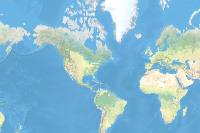

In [2]:
from arcgis.apps.itemgraph import create_dependency_graph
surv_id = "02d0702e1ef0468083f780791670c969"
surv = gis.content.get(surv_id)
surv

In [3]:
ig = create_dependency_graph(gis = gis, item_list = [surv])
ig.all_items()

[ItemNode(id: 02d0702e1ef0468083f780791670c969, item: San Diego Parrot Sightings),
 ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: 41dd3cca32914cc7ae8fd3a727f44e17, item: San Diego Parrot Sightings),
 ItemNode(id: d818128edbab44099238bc44e4bf2df0, item: summary_individual_temp),
 ItemNode(id: 447ef32f6431488c9f9d7552f7d20ce0, item: individual_temp),
 ItemNode(id: 588f0e0acc514c11bc7c898fed9fc651, item: Topographic),
 ItemNode(id: 6a5d407b62954806ac31558c6774656f, item: summary_temp),
 ItemNode(id: 9fccd6b78482414994eb2c19f90a44c8, item: San Diego Parrot Sightings_form)]

In [5]:
ig.all_items("id")

['02d0702e1ef0468083f780791670c969',
 'a7192e06cfb446e1bab59849285e1038',
 '41dd3cca32914cc7ae8fd3a727f44e17',
 'd818128edbab44099238bc44e4bf2df0',
 '447ef32f6431488c9f9d7552f7d20ce0',
 '588f0e0acc514c11bc7c898fed9fc651',
 '6a5d407b62954806ac31558c6774656f',
 '9fccd6b78482414994eb2c19f90a44c8']

In [6]:
survey_node = ig.get_node(surv_id)
survey_node

ItemNode(id: 02d0702e1ef0468083f780791670c969, item: San Diego Parrot Sightings)

<Item title:"San Diego Parrot Sightings" type:Form owner:nparavicini_geosaurus>
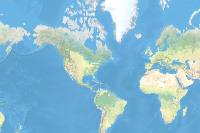

In [7]:
survey_node.item

In [8]:
# contains() = items immediately used/referenced by the survey item
survey_node.contains()

[ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: d818128edbab44099238bc44e4bf2df0, item: summary_individual_temp),
 ItemNode(id: 447ef32f6431488c9f9d7552f7d20ce0, item: individual_temp),
 ItemNode(id: 588f0e0acc514c11bc7c898fed9fc651, item: Topographic),
 ItemNode(id: 6a5d407b62954806ac31558c6774656f, item: summary_temp),
 ItemNode(id: 9fccd6b78482414994eb2c19f90a44c8, item: San Diego Parrot Sightings_form)]

In [9]:
# requires() = every item needed for the survey to exist
survey_node.requires()

[ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: 41dd3cca32914cc7ae8fd3a727f44e17, item: San Diego Parrot Sightings),
 ItemNode(id: 588f0e0acc514c11bc7c898fed9fc651, item: Topographic),
 ItemNode(id: 447ef32f6431488c9f9d7552f7d20ce0, item: individual_temp),
 ItemNode(id: d818128edbab44099238bc44e4bf2df0, item: summary_individual_temp),
 ItemNode(id: 9fccd6b78482414994eb2c19f90a44c8, item: San Diego Parrot Sightings_form),
 ItemNode(id: 6a5d407b62954806ac31558c6774656f, item: summary_temp)]

In [10]:
# conversely, we can grab a dependent item and see what items immediately contain it and need it to exist
result_form = ig.get_node("41dd3cca32914cc7ae8fd3a727f44e17")
result_form.item

<Item title:"San Diego Parrot Sightings" type:Feature Layer Collection owner:nparavicini_geosaurus>

In [11]:
# contained_by() = items in the graph that immediately use/reference this feature layer item
result_form.contained_by()

[ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: 9fccd6b78482414994eb2c19f90a44c8, item: San Diego Parrot Sightings_form)]

In [12]:
# required_by() = every item in the graph that needs this feature layer item to exist
result_form.required_by()

[ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: 9fccd6b78482414994eb2c19f90a44c8, item: San Diego Parrot Sightings_form),
 ItemNode(id: 02d0702e1ef0468083f780791670c969, item: San Diego Parrot Sightings)]

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

def generate_labels(item_graph):
    labels = {}
    nodes = item_graph.nodes()
    for node_name in nodes:
        node = item_graph.get_node(node_name)
        if node.item:
            node_label = f"{node.item.title}\n({node.item.type})"
            labels[node_name] = node_label
        else:
            labels[node_name] = f"{str(node_name)}\n(Unknown Type)"
    return labels

def plot_graph(item_graph, root):
    
    # get the labels
    labels = generate_labels(item_graph)
    
    # Create a tree graph (for example, a balanced binary tree)
    tree = nx.bfs_tree(item_graph, root)
    
    # Use graphviz_layout for a clean tree layout
    pos = nx.nx_pydot.graphviz_layout(tree, prog="dot", root = root)
    
    # Draw the graph
    plt.figure(figsize=(10, 6))
    nx.draw(item_graph, pos, with_labels=True, labels=labels, arrows=False, node_size=500, node_color="lightblue", font_size = 7)
    plt.show()

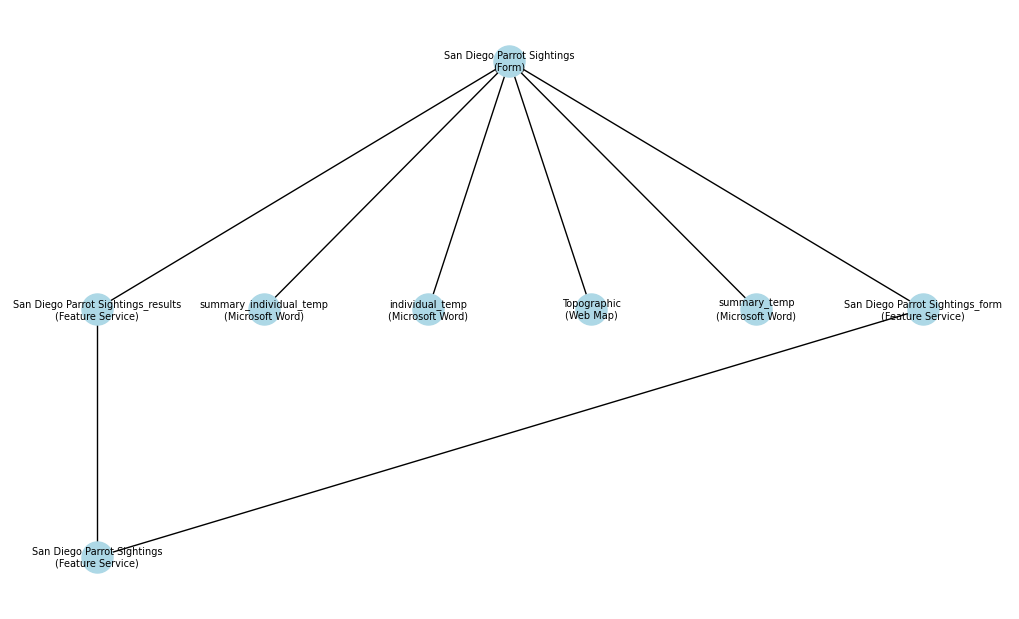

In [14]:
plot_graph(ig, surv_id)

In [15]:
storymap_list = gis.content.search(query="type:StoryMap owner:nparavicini_geosaurus", max_items = 20)
storymap_list

[<Item title:"(Copy) Cerulean City" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Test sidecar cloning" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this story" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Cloning Stuff" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Oregon" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this story" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Cerulean City" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this story" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"test the mapping!" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this story" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Yerrrrrrr" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Why won't this work?" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this story" type:StoryMap owner:nparavicini_geosaurus>,
 <Item title:"Copy this sto

In [16]:
sm_id = storymap_list[-1].id
storymap_ig = create_dependency_graph(gis, [sm_id])
storymap_ig.all_items()

[ItemNode(id: fd5801d2f66b43e1a20146d8761f758b, item: Oh heavens),
 ItemNode(id: 7099b3c2e979415e975d00e58afed77e, item: Map that should totally work),
 ItemNode(id: 0384ujr43n53490890843t543ojf809re),
 ItemNode(id: baaf98d1695f47db8d5dc701c0e5f864, item: Read-Only CA/OR Airports),
 ItemNode(id: 273bf8d5c8ac400183fc24e109d20bcf, item: Community),
 ItemNode(id: faa67b0af7914a2f9f4d96c561816c6e),
 ItemNode(id: 35983e54e61a40b8ac03148e197452ac, item: PLACES: Arthritis)]

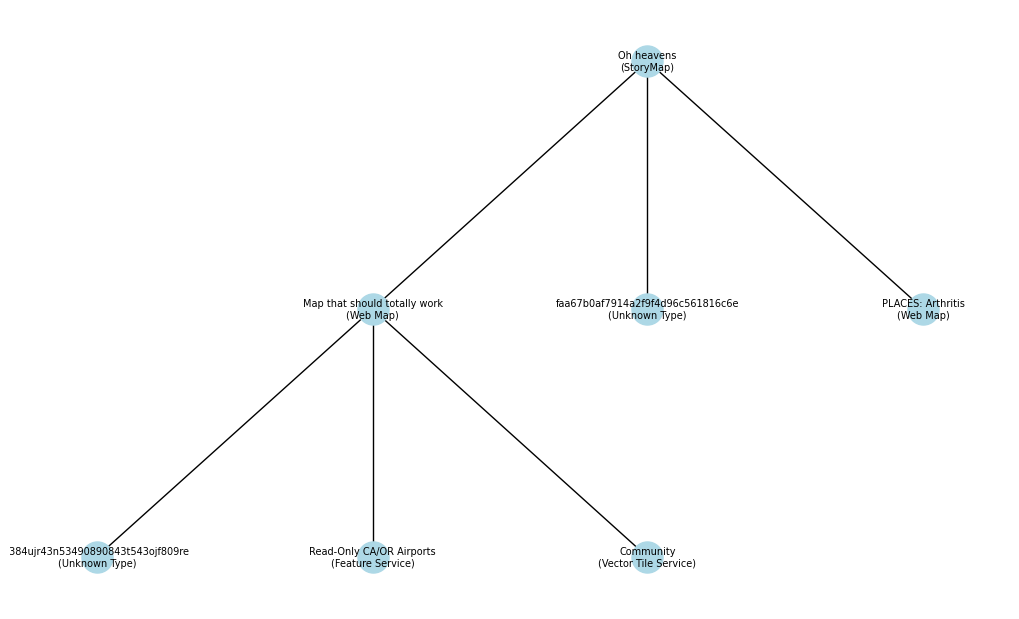

In [17]:
plot_graph(storymap_ig, sm_id)

In [18]:
sm = gis.content.get(sm_id)

In [21]:
sm.get_data()

{'root': 'n-RDKFmb',
 'nodes': {'n-OgoRz7': {'type': 'storycover',
   'data': {'type': 'minimal',
    'title': 'Oh heavens',
    'summary': "What's going on here?",
    'byline': 'Noah Paravicini',
    'titlePanelVerticalPosition': 'top',
    'titlePanelHorizontalPosition': 'start',
    'titlePanelStyle': 'gradient'}},
  'n-AyFYrR': {'type': 'navigation',
   'data': {'links': []},
   'config': {'isHidden': True}},
  'n-DtrqXH': {'type': 'webmap',
   'data': {'map': 'r-7099b3c2e979415e975d00e58afed77e',
    'caption': 'Map that should totally work',
    'timeSlider': False,
    'viewPlacement': 'extent',
    'extent': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
     'xmin': -13211692.257711152,
     'ymin': 4016120.783053469,
     'xmax': -13153129.89903166,
     'ymax': 4049065.1422443353},
    'center': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
     'x': -13182411.078371406,
     'y': 4032592.962648902},
    'zoom': 10.730486008837465,
    'viewpoint': 